<div align="center">

# ✈️ CS 6330 Data Science Project
## Global Aviation Infrastructure Analysis

**Name**: Voleak Lim  
**CID**: 81488194  
**Contact**: vlim2@angelo.edu  
**GitHub**: https://github.com/limvoleak1128/CS-6330-aviation-project

---
</div>

## Project Idea

This project examines how physical infrastructure shapes global air
connectivity. Specifically, it investigates whether airport elevation,
geographic position, and airport size influence the distance and type
of routes an airport can support. Rather than treating aviation purely
as an economic or demand-driven network, this analysis approaches it
from an infrastructure perspective — asking whether the physical
characteristics of an airport constrain or define its role in the
global flight network. By integrating airline, airport, and route data,
the project applies regression, classification, and clustering methods
to uncover patterns that predefined labels and conventional assumptions
do not fully capture.

## Project Goals
This project investigates global aviation through six analytical goals:

1. Data Integration: Successfully merge the airlines, airports, and routes
   datasets into a single unified master dataset for analysis.

2. Infrastructure Analysis: Investigate whether source airport elevation
   significantly influences route distance, using latitude and longitude
   as geographic supporting features.

3. Route Type Analysis: Classify routes as domestic or international based on
   geographic and infrastructure features.

4. Traffic Dominance Analysis: Identify the top countries by total inbound
   and outbound flight volume, detect countries where a single airline controls
   more than 70% of routes, and map the most intense continent-to-continent
   traffic corridors.

5. Capacity Analysis: Examine whether medium-sized airports exist that handle
   a disproportionately high number of routes relative to large airports,
   challenging the assumption that airport size determines route capacity.

6. Missing Value Study: Investigate whether empty callsign entries represent
   unrecorded data or airlines that genuinely operate without a callsign.
   **Note**: This goal was set aside during the discovery phase after revealing
   395 missing values, making manual verification impractical. The missing
   values are handled with an 'Unknown' placeholder instead.

<div align="center">

### Project Goal Tracker

| Goal | Description | Section | Method |
|:---:|:---|:---:|:---|
| 1 | Data Integration | 1.1 Data Wrangling | Merging airlines, airports, and routes datasets |
| 2 | Infrastructure Analysis | 2.1 & 2.2 Regression | Simple & Multiple Linear Regression |
| 3 | Route Type Analysis | 2.3 Regression & 4 Supervised Learning | Logistic Regression & SVM |
| 4 | Traffic Dominance Analysis | 1.3 Descriptive Analysis | Aggregation & Visualization |
| 5 | Capacity Analysis | 1.3 Descriptive Analysis | Aggregation & Visualization |
| 6 | Missing Value Study | 1.1 Data Wrangling | Dropped — insufficient data for manual verification |

</div>

> **Note**: Sections 3 (Evaluate Model Performance) and 5 (Unsupervised
> Learning) do not directly answer a specific goal but play an essential
> role in the project. Section 3 validates the reliability of the
> regression models built in Section 2, ensuring the goal answers are
> trustworthy rather than coincidental. Section 5 extends the
> infrastructure analysis by discovering airport groupings from the data
> itself, providing a broader perspective on how physical and geographic
> features shape the global aviation network. Notably, the clustering
> results also reinforce Goal 5.

# Dataset

- **URL**: https://www.kaggle.com/datasets/darkmatternet/global-flights-airports-airlines/data?select=airlines.csv
- **Description**: This dataset integrates three primary aviation files:
  Airports, Airlines, and Routes. By combining crowdsourced airport and
  airline data with commercial route information, the dataset provides a
  comprehensive view of global connectivity, including small regional
  airfields and inactive carriers.
- **Columns and key features**:
  1. Airports Table (85,116 rows × 19 columns): elevation_ft, type,
     continent, iso_country, and iata_code
  2. Airlines Table (1,536 rows × 8 columns): callsign, airline_name,
     and iata_code
  3. Routes Table (66,379 rows × 19 columns): distance_km, airline_name,
     src_iata, dst_iata, airline_iata, src_country, and dst_country
- **Merged Identifiers**: IATA codes used by airlines and airports,
  including IATA 2-letter and 3-letter codes.

This notebook covers model performance evaluation. The necessary libraries
are loaded below, along with the cleaned and merged master dataset produced
in exploration.ipynb. The regression models are rebuilt here to serve as
the basis for evaluation.

In [4]:
# ── Standard libraries ────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.simplefilter("ignore")

# ── Visualization ─────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# ── Scikit-learn: Models ──────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression, LogisticRegression

# ── Scikit-learn: Preprocessing & Model Selection ─────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils import resample

# ── Scikit-learn: Metrics ──────────────────────────────────────────────────
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    log_loss, make_scorer, accuracy_score, silhouette_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)

In [5]:
# ── Mount Google Drive to access dataset files stored in Drive ────────────
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# ── Define file path and load the the merge dataset into dataframes ─────
path = '/content/drive/My Drive/CS-6330-aviation-project/dataset/final_cleaned_flight_data.csv'

# keep_default_na=False preserves Namibia's ISO country code 'NA' as a string
master_df = pd.read_csv(path, keep_default_na=False, na_values=[''])    # cleaned and merged dataset produced in exploration.ipynb

# 2. Regression

During initial exploration, the scatter plot of distance_km vs. src_elevation
revealed a weak linear correlation, confirming that elevation alone cannot
explain the vast differences in global flight distances. However, rather than
dropping elevation, we incorporate latitude and longitude as supporting features  based on a key insight: an airport's altitude is geographically dependent —  high-elevation airports tend to cluster in specific regions

The three features each capture a different dimension of airport infrastructure:
- src_elevation: the vertical dimension — higher altitudes impose physical
  constraints on aircraft operations and connectivity.
- src_lat: the north-south position — major economic hubs are historically
  concentrated in specific latitudinal bands, particularly the Northern Hemisphere.
- src_lon: the east-west position — allows the model to capture the major
  transcontinental corridors that define global flight flow.

Two geographic supporting features are engineered from
the existing latitude and longitude columns: `lat_diff` (the absolute difference in latitude between source and destination airports) and `lon_diff` (the absolute difference in longitude).

A binary target variable `is_international` is also
created, where 1 indicates the route crosses a country border and 0 indicates
a domestic route.

In [7]:
# Feature engineering
master_df['lat_diff'] = abs(master_df['dst_lat'] - master_df['src_lat'])
master_df['lon_diff'] = abs(master_df['dst_lon'] - master_df['src_lon'])
master_df['is_international'] = (master_df['src_country'] != master_df['dst_country']).astype(int)

print('New features added: lat_diff, lon_diff, is_international')
print(master_df[['src_elevation', 'dst_elevation', 'lat_diff', 'lon_diff', 'distance_km', 'is_international']].describe())

New features added: lat_diff, lon_diff, is_international
       src_elevation  dst_elevation      lat_diff      lon_diff   distance_km  \
count   66378.000000   66378.000000  6.637800e+04  66378.000000  66378.000000   
mean      232.421679     233.397661  9.039284e+00     17.126631   1842.588508   
std       453.298653     454.103476  9.958137e+00     31.940994   2025.654164   
min       -21.945600     -21.945600  1.600000e-07      0.000045      3.000000   
25%        10.972800      10.972800  2.512242e+00      3.199259    617.000000   
50%        53.949600      53.949600  6.201318e+00      7.614005   1184.000000   
75%       207.568800     208.788000  1.215340e+01     17.007709   2159.000000   
max      4411.065600    4411.065600  8.713080e+01    359.217586  13808.000000   

       is_international  
count      66378.000000  
mean           0.508979  
std            0.499923  
min            0.000000  
25%            0.000000  
50%            1.000000  
75%            1.000000  
max  

> 📌 **Project Goal 2 — Infrastructure Analysis**: Investigate whether source
> airport elevation significantly influences route distance, using latitude and
> longitude as geographic supporting features (Single Linear Regression and Multiple Linear Regression).

## 2.1 Single Linear Regression

The Question: Does airport elevation significantly impact the distance of routes?

Use LinearRegression to examine whether airport elevation
at the source airport (src_elevation) can predict the route distance (distance_km). Elevation is selected as the independent variable because it is the primary infrastructure feature of interest in this project. The dataset is split into 80% training and 20% testing sets. Model performance
is measured using MSE, RMSE, and MAE, and the results are visualised with
a regression line plot and an observed vs predicted scatter plot.

In [8]:
# ── Data preparation ───────────────────────────────────────────────────────
slr_data = master_df[['src_elevation', 'distance_km']].dropna()

X_slr = slr_data[['src_elevation']].values
y_slr = slr_data['distance_km'].values

X_slr_train, X_slr_test, y_slr_train, y_slr_test = train_test_split(
    X_slr, y_slr, test_size=0.2, random_state=42
)

# ── Model ──────────────────────────────────────────────────────────────────
slr_model = LinearRegression()
slr_model.fit(X_slr_train, y_slr_train)

y_slr_pred = slr_model.predict(X_slr_test)

print('Simple Linear Regression: src_elevation → distance_km')
print(f'  Intercept  : {slr_model.intercept_:.4f}')
print(f'  Coefficient: {slr_model.coef_[0]:.4f}  (src_elevation)')
print(f'  R²         : {r2_score(y_slr_test, y_slr_pred):.4f}')

Simple Linear Regression: src_elevation → distance_km
  Intercept  : 1918.4514
  Coefficient: -0.3075  (src_elevation)
  R²         : 0.0048


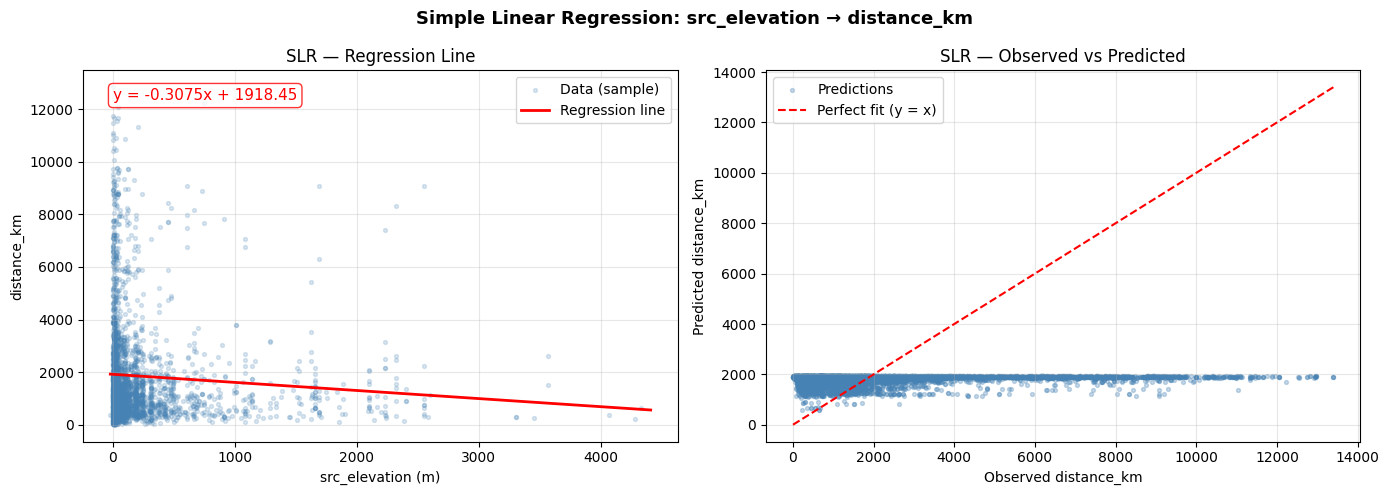

In [9]:
# ── Plot: Observed vs Predicted ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: regression line over scatter
ax1 = axes[0]
sample = slr_data.sample(3000, random_state=42)
ax1.scatter(sample['src_elevation'], sample['distance_km'],
            alpha=0.2, s=8, color='steelblue', label='Data (sample)')
x_line = np.linspace(X_slr.min(), X_slr.max(), 200).reshape(-1, 1)
ax1.plot(x_line, slr_model.predict(x_line), color='red', linewidth=2,
         label='Regression line')
ax1.set_xlabel('src_elevation (m)')
ax1.set_ylabel('distance_km')
ax1.set_title('SLR — Regression Line')
ax1.legend()
ax1.grid(alpha=0.3)

# Build equation string
intercept  = slr_model.intercept_
coef       = slr_model.coef_[0]
sign       = '+' if intercept >= 0 else '-'
equation   = f'y = {coef:.4f}x {sign} {abs(intercept):.2f}'

# Place it on the plot
ax1.text(
    0.05, 0.92, equation,
    transform=ax1.transAxes,
    fontsize=11,
    color='red',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='red', alpha=0.8)
)

# Right: observed vs predicted
ax2 = axes[1]
ax2.scatter(y_slr_test, y_slr_pred, alpha=0.3, s=8, color='steelblue', label='Predictions')
lims = [min(y_slr_test.min(), y_slr_pred.min()), max(y_slr_test.max(), y_slr_pred.max())]
ax2.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit (y = x)')
ax2.set_xlabel('Observed distance_km')
ax2.set_ylabel('Predicted distance_km')
ax2.set_title('SLR — Observed vs Predicted')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('Simple Linear Regression: src_elevation → distance_km',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
# ── Loss functions ─────────────────────────────────────────────────────────
slr_mse  = mean_squared_error(y_slr_test, y_slr_pred)
slr_rmse = np.sqrt(slr_mse)
slr_mae  = mean_absolute_error(y_slr_test, y_slr_pred)
slr_r2   = r2_score(y_slr_test, y_slr_pred)

print('SLR Loss Functions')
print(f'  MSE  : {slr_mse:>12,.2f}')
print(f'  RMSE : {slr_rmse:>12,.2f}')
print(f'  MAE  : {slr_mae:>12,.2f}')
print(f'  R²   : {slr_r2:>12,.4f}')

SLR Loss Functions
  MSE  : 3,968,694.88
  RMSE :     1,992.16
  MAE  :     1,340.45
  R²   :       0.0048


**Interpretation of Results**

Elevation alone shows a weak negative relationship with route distance (r^2 =  0.0048). The low R² is expected and honest — it tells us that airport altitude by itself is not a strong predictor of how far a route flies. To put this in practical terms, the model predicts that for every 1 meter increase in airport elevation, route distance decreases by approximately 0.31 km. While this sounds meaningful, the average route in this dataset spans 1,842 km, meaning elevation alone moves the prediction by less than 0.02% per meter. Even across the full observed elevation range — from -22m below sea level to 4,411m — the total predicted effect is only 1,363 km, which reflects the weak and noisy relationship rather than a reliable prediction signal, consistent with the R² of 0.0048.

This motivates the multiple regression, where we control for geographic position to better isolate elevation's true contribution.

## 2.2 Multiple Linear Regression

The Question: Can we predict how long a flight route is, using elevation and geographic position together?

In [11]:
# ── Data preparation ───────────────────────────────────────────────────────
mlr_features = ['src_elevation', 'dst_elevation', 'lat_diff', 'lon_diff']
mlr_data = master_df[mlr_features + ['distance_km']].dropna()

X_mlr = mlr_data[mlr_features].values
y_mlr = mlr_data['distance_km'].values

X_mlr_train, X_mlr_test, y_mlr_train, y_mlr_test = train_test_split(
    X_mlr, y_mlr, test_size=0.2, random_state=42
)

# ── Model ──────────────────────────────────────────────────────────────────
mlr_model = LinearRegression()
mlr_model.fit(X_mlr_train, y_mlr_train)

y_mlr_pred = mlr_model.predict(X_mlr_test)

print('Multiple Linear Regression')
print(f'  R²: {r2_score(y_mlr_test, y_mlr_pred):.4f}')
print('\n  Coefficients:')
for feat, coef in zip(mlr_features, mlr_model.coef_):
    print(f'    {feat:<20}: {coef:.4f}')
print(f'  Intercept: {mlr_model.intercept_:.4f}')

# ── Print equation ─────────────────────────────────────────────────────────
terms = []
for feat, coef in zip(mlr_features, mlr_model.coef_):
    sign = '+' if coef >= 0 else '-'
    terms.append(f'{sign} {abs(coef):.4f}×{feat}')

intercept_sign = '+' if mlr_model.intercept_ >= 0 else '-'
equation = (f'\n  Equation:\n  distance_km = '
            + ' '.join(terms)
            + f' {intercept_sign} {abs(mlr_model.intercept_):.2f}')
print(equation)

Multiple Linear Regression
  R²: 0.8468

  Coefficients:
    src_elevation       : 0.0160
    dst_elevation       : 0.0170
    lat_diff            : 97.1345
    lon_diff            : 41.7833
  Intercept: 242.2077

  Equation:
  distance_km = + 0.0160×src_elevation + 0.0170×dst_elevation + 97.1345×lat_diff + 41.7833×lon_diff + 242.21


In [12]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data['Feature'] = mlr_features
vif_data['VIF'] = [variance_inflation_factor(X_mlr_train, i)
                   for i in range(X_mlr_train.shape[1])]
print('\n  Variance Inflation Factor (VIF):')
print(vif_data.to_string(index=False))
print('\n  (VIF > 10 indicates high multicollinearity)')


  Variance Inflation Factor (VIF):
      Feature      VIF
src_elevation 1.227319
dst_elevation 1.227175
     lat_diff 1.438180
     lon_diff 1.342190

  (VIF > 10 indicates high multicollinearity)


The 3D plot uses src_elevation and lat_diff as the two axes alongside
distance_km because these represent the two most analytically contrasting
features in the model — src_elevation being the primary infrastructure
variable of interest, and lat_diff being the strongest geographic predictor.
Plotting these two together visually demonstrates how geographic separation
dominates the prediction while elevation plays a secondary role.

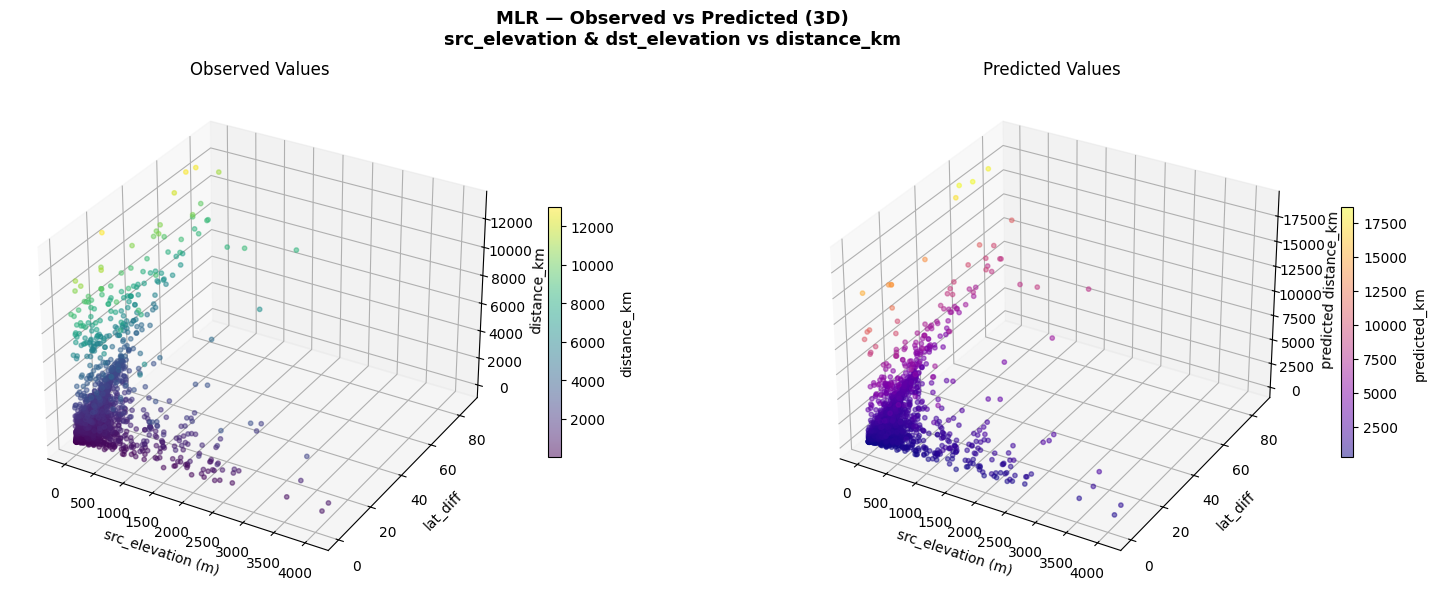

In [13]:
# ── 3D Plot: src_elevation & lat_diff vs distance_km ──────────────────
sample_idx = np.random.choice(len(X_mlr_test), size=min(2000, len(X_mlr_test)), replace=False)
X_plot     = X_mlr_test[sample_idx]
y_obs      = y_mlr_test[sample_idx]
y_pred_plot = y_mlr_pred[sample_idx]

# src_elevation = index 0, lat_diff = index 2
elev_src = X_plot[:, 0]
lat      = X_plot[:, 2]
fig = plt.figure(figsize=(16, 6))

# Subplot 1: Observed
ax1 = fig.add_subplot(121, projection='3d')
sc1 = ax1.scatter(elev_src, lat, y_obs,
                  c=y_obs, cmap='viridis', alpha=0.5, s=10)
ax1.set_xlabel('src_elevation (m)')
ax1.set_ylabel('lat_diff')
ax1.set_zlabel('distance_km')
ax1.set_title('Observed Values')
fig.colorbar(sc1, ax=ax1, shrink=0.5, label='distance_km')

# Subplot 2: Predicted
ax2 = fig.add_subplot(122, projection='3d')
sc2 = ax2.scatter(elev_src, lat, y_pred_plot,
                  c=y_pred_plot, cmap='plasma', alpha=0.5, s=10)
ax2.set_xlabel('src_elevation (m)')
ax2.set_ylabel('lat_diff')
ax2.set_zlabel('predicted distance_km')
ax2.set_title('Predicted Values')
fig.colorbar(sc2, ax=ax2, shrink=0.5, label='predicted_km')

fig.suptitle('MLR — Observed vs Predicted (3D)\nsrc_elevation & dst_elevation vs distance_km',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
# ── Loss functions ─────────────────────────────────────────────────────────
mlr_mse  = mean_squared_error(y_mlr_test, y_mlr_pred)
mlr_rmse = np.sqrt(mlr_mse)
mlr_mae  = mean_absolute_error(y_mlr_test, y_mlr_pred)
mlr_r2   = r2_score(y_mlr_test, y_mlr_pred)

print('MLR Loss Functions')
print(f'  MSE  : {mlr_mse:>12,.2f}')
print(f'  RMSE : {mlr_rmse:>12,.2f}')
print(f'  MAE  : {mlr_mae:>12,.2f}')
print(f'  R²   : {mlr_r2:>12,.4f}')

MLR Loss Functions
  MSE  :   610,812.53
  RMSE :       781.54
  MAE  :       345.35
  R²   :       0.8468


**Interpretation of Results**

The fitted model produces the equation:

distance_km = 0.0160×src_elevation + 0.0170×dst_elevation
            + 97.13×lat_diff + 41.78×lon_diff + 242.21

Adding lat/lon differences alongside both elevation features significantly improves R² (0.8468) compared to SLR (0.0048).

The sign change on src_elevation between the simple and multiple regression models is a natural consequence of adding new features, not a sign of problematic multicollinearity — the VIF scores for all four features fall between 1.2 and 1.4, confirming that the features are largely independent of each other. In the simple model, src_elevation was the only predictor, so it unintentionally absorbed some geographic variation alongside its own effect. Once lat_diff and lon_diff were introduced, they took over the geographic explanation, leaving src_elevation to reflect only its own small, isolated effect on route distance — which settles at +0.016, a practically negligible value. This is precisely why incorporating latitude and longitude as supporting features is necessary — it allows elevation's true contribution to be studied in its proper geographic context, rather than as a mixed signal.

A residual plot is used to validate the MLR model by checking whether
the prediction errors are randomly distributed. If the residuals scatter
randomly around zero with no clear pattern, it confirms that the model
has captured the underlying relationship well. A systematic pattern in
the residuals would suggest the model is missing an important feature
or that the relationship is non-linear.

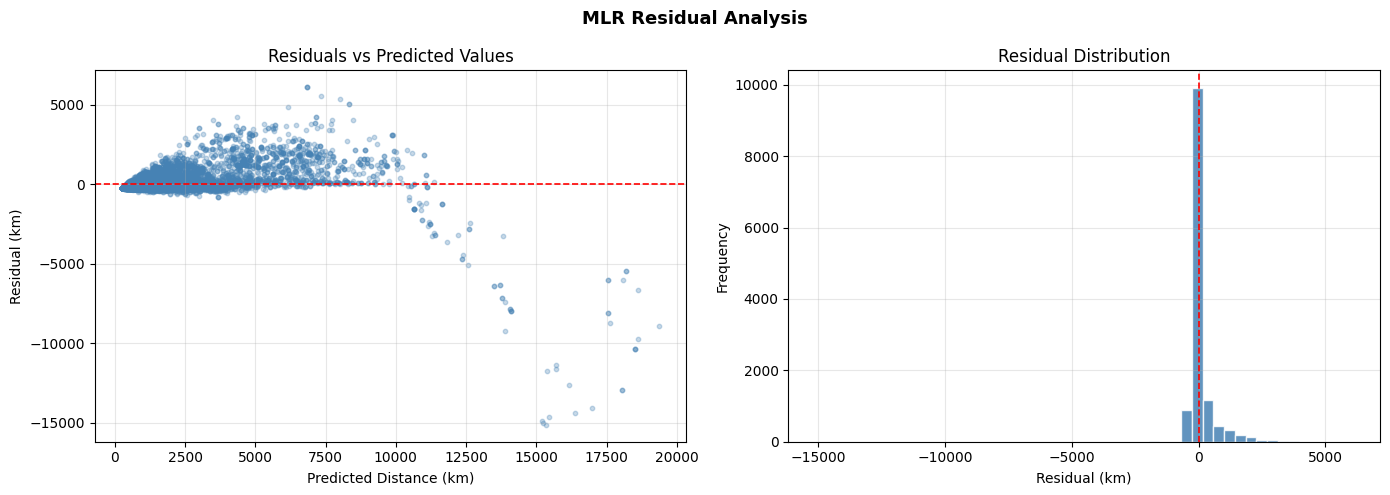

Mean residual : -4.69 km
Std of residuals: 781.53 km


In [15]:
# ── Residual plot for MLR ─────────────────────────────────────────────────
residuals = y_mlr_test - y_mlr_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('MLR Residual Analysis', fontsize=13, fontweight='bold')

# Panel 1 — Residuals vs Predicted
ax1 = axes[0]
ax1.scatter(y_mlr_pred, residuals, alpha=0.3, s=10, color='steelblue')
ax1.axhline(0, color='red', linestyle='--', linewidth=1.2)
ax1.set_title('Residuals vs Predicted Values')
ax1.set_xlabel('Predicted Distance (km)')
ax1.set_ylabel('Residual (km)')
ax1.grid(alpha=0.3)

# Panel 2 — Residual distribution
ax2 = axes[1]
ax2.hist(residuals, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
ax2.axvline(0, color='red', linestyle='--', linewidth=1.2)
ax2.set_title('Residual Distribution')
ax2.set_xlabel('Residual (km)')
ax2.set_ylabel('Frequency')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Mean residual : {residuals.mean():.2f} km')
print(f'Std of residuals: {residuals.std():.2f} km')

**Interpretation of Results**

The residual plot reveals that the MLR model performs well for short
to medium haul routes, where residuals scatter closely around zero
with no strong pattern. However, for very long routes above 10,000 km,
the residuals drop sharply into large negative values, indicating that
the model consistently overestimates distances at the upper extreme.
This fan-shaped pattern, known as heteroscedasticity, suggests that
the model's prediction error grows as route distance increases.

This is an expected limitation — ultra-long-haul routes involve complex
geographic paths that simple latitude and longitude differences cannot
fully capture. The residual distribution confirms this, showing that
while most errors are small and centered near zero, a tail of large
negative residuals pulls the standard deviation to 781.53 km. The model
remains reliable for the majority of routes in the dataset, but its
precision decreases for the most extreme long-haul connections.

> ✅ **Goal 2 answered — Infrastructure Analysis**: Source airport elevation
> alone is not a significant predictor of route distance, explaining only
> 0.48% of variance (R² = 0.0048). However, when latitude and longitude
> differences are added as geographic supporting features, the model explains
> 84.68% of route distance variance (R² = 0.8468), confirming that geographic
> position is the dominant driver of route distance while elevation plays a
> secondary supporting role.

## 2.3 Logistic Regression

> 📌 **Project Goal 3 — Route Type Analysis (Part 1)**: Classify routes as
> domestic or international based on elevation and distance features.

The Question: Can we predict whether a route is international or domestic, based on elevation and distance?

LogisticRegression to classify whether a flight route
is international (crossing a country border) or domestic (within the same country).  The target variable is_international is binary: 1 for international and 0 for domestic. The features used are src_elevation, dst_elevation, and distance_km — keeping elevation as the central focus while distance provides additional discriminative signal. Features are standardised using StandardScaler before fitting, as logistic regression is sensitive to feature scale. erformance is reported using absolute loss and log loss, and results are visualised through a predicted probability distribution and a
scatter plot coloured by predicted class.

In [16]:
# ── Data preparation ───────────────────────────────────────────────────────
log_features = ['src_elevation', 'dst_elevation', 'distance_km']
log_data = master_df[log_features + ['is_international']].dropna()

X_log = log_data[log_features].values
y_log = log_data['is_international'].values

X_log_train, X_log_test, y_log_train, y_log_test = train_test_split(
    X_log, y_log, test_size=0.2, random_state=42, stratify=y_log
)

# Scale (important for logistic regression)
scaler = StandardScaler()
X_log_train_sc = scaler.fit_transform(X_log_train)
X_log_test_sc  = scaler.transform(X_log_test)

# ── Model ──────────────────────────────────────────────────────────────────
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_log_train_sc, y_log_train)

y_log_pred       = log_model.predict(X_log_test_sc)
y_log_pred_proba = log_model.predict_proba(X_log_test_sc)[:, 1]

print('Logistic Regression: src_elevation + dst_elevation + distance_km → is_international')
print(f'  Accuracy: {np.mean(y_log_pred == y_log_test):.4f}')
print('\n  Coefficients:')
for feat, coef in zip(log_features, log_model.coef_[0]):
    print(f'    {feat:<20}: {coef:.4f}')

Logistic Regression: src_elevation + dst_elevation + distance_km → is_international
  Accuracy: 0.7239

  Coefficients:
    src_elevation       : -0.2288
    dst_elevation       : -0.2227
    distance_km         : 1.9611


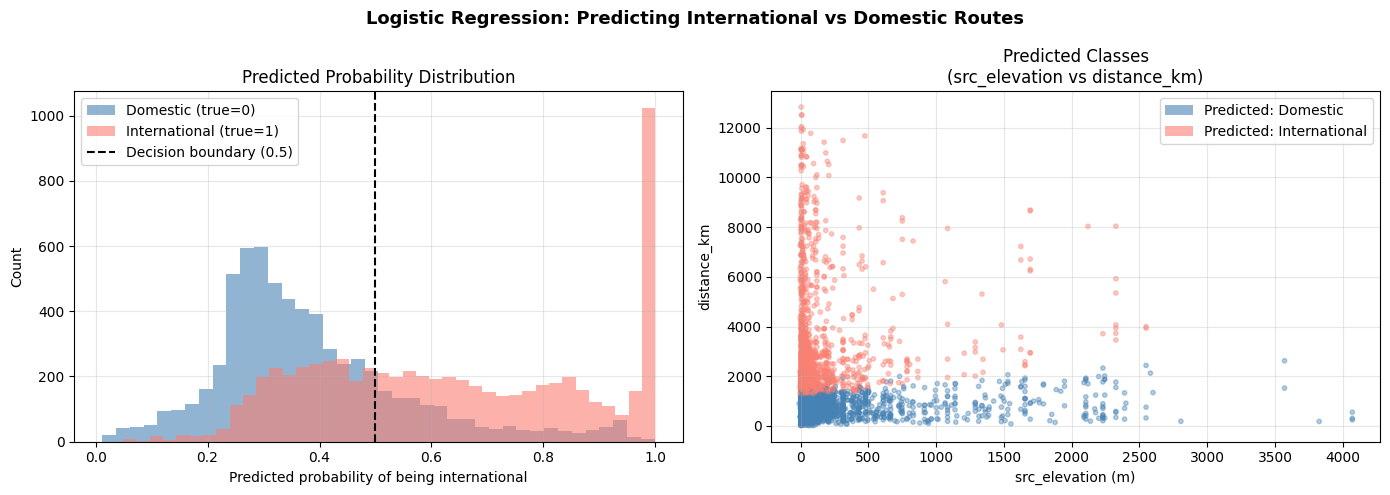

In [17]:
# ── Plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: predicted probability distribution by true class
ax1 = axes[0]
ax1.hist(y_log_pred_proba[y_log_test == 0], bins=40, alpha=0.6,
         color='steelblue', label='Domestic (true=0)')
ax1.hist(y_log_pred_proba[y_log_test == 1], bins=40, alpha=0.6,
         color='salmon', label='International (true=1)')
ax1.axvline(0.5, color='black', linestyle='--', linewidth=1.5,
            label='Decision boundary (0.5)')
ax1.set_xlabel('Predicted probability of being international')
ax1.set_ylabel('Count')
ax1.set_title('Predicted Probability Distribution')
ax1.legend()
ax1.grid(alpha=0.3)

# Right: src_elevation vs distance_km coloured by predicted class
ax2 = axes[1]
sample_size = min(3000, len(y_log_test))
idx = np.random.choice(len(y_log_test), size=sample_size, replace=False)
colors = ['steelblue' if p == 0 else 'salmon' for p in y_log_pred[idx]]
ax2.scatter(X_log_test[idx, 0], X_log_test[idx, 2],   # src_elevation vs distance_km
            c=colors, alpha=0.4, s=10)
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue', alpha=0.6, label='Predicted: Domestic'),
    Patch(facecolor='salmon',    alpha=0.6, label='Predicted: International')
]
ax2.legend(handles=legend_elements)
ax2.set_xlabel('src_elevation (m)')
ax2.set_ylabel('distance_km')
ax2.set_title('Predicted Classes\n(src_elevation vs distance_km)')
ax2.grid(alpha=0.3)

plt.suptitle('Logistic Regression: Predicting International vs Domestic Routes',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
# ── Loss functions ─────────────────────────────────────────────────────────
abs_loss = 1 - np.mean(y_log_pred == y_log_test)
ll       = log_loss(y_log_test, y_log_pred_proba)

print('Logistic Regression Loss Functions')
print(f'  Absolute loss (1 − accuracy): {abs_loss:.4f}')
print(f'  Log loss                    : {ll:.4f}')
print(f'  Accuracy                    : {1 - abs_loss:.4f}')

Logistic Regression Loss Functions
  Absolute loss (1 − accuracy): 0.2761
  Log loss                    : 0.5476
  Accuracy                    : 0.7239


**Interpretation of Results**

Even with only elevation and distance as predictors, the logistic model classifies domestic vs international routes at a reasonable accuracy (0.7239). The distance_km coefficient is strongly positive — longer routes are more likely to be international. Both elevation features carry negative coefficients, meaning high-elevation airports lean toward domestic service, consistent with what we observed in the regression models. This reinforces the infrastructure story: high-altitude airports, often in mountainous or landlocked regions, tend to serve local rather than international traffic.

The confusion matrix breaks down the model's predictions into four
categories — true positives, true negatives, false positives, and false
negatives. This gives a more detailed picture of model performance than
accuracy alone, showing whether the model struggles more with one class
than the other.

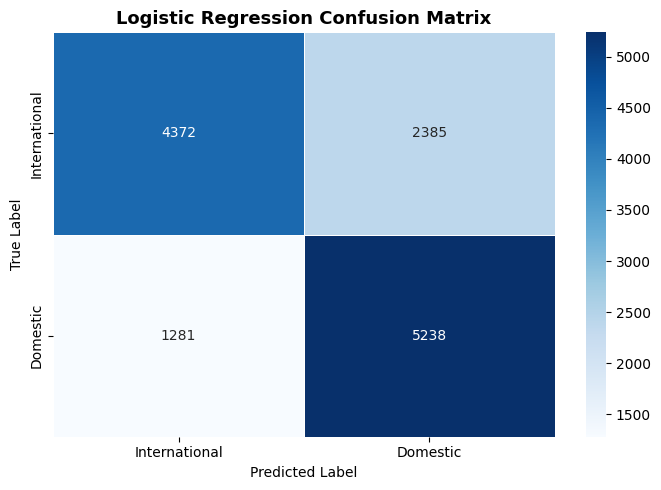

In [19]:
# ── Confusion matrix for Logistic Regression ─────────────────────────────
cm_log = confusion_matrix(y_log_test, y_log_pred, labels=[1, 0])

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues',
            xticklabels=['International', 'Domestic'],
            yticklabels=['International', 'Domestic'],
            linewidths=0.5, ax=ax)
ax.set_title('Logistic Regression Confusion Matrix',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.show()

**Interpretation of Results**

The confusion matrix shows that the model correctly identified 5,238
domestic routes and 4,372 international routes. However, it misclassified
1,281 domestic routes as international and 2,385 international routes as
domestic. The higher misclassification of international routes as domestic
suggests that the model has a slight tendency to predict domestic. This is
consistent with distance_km being the dominant feature — some international
routes between neighboring countries, particularly in Europe, are very short
in distance and therefore closely resemble domestic routes, making them
difficult for the model to correctly identify as international.

## Conclusion

The regression section answered a question that is easy to assume but
harder to prove — that geography matters more than altitude in aviation.
Elevation alone explains almost nothing about route distance, but the
moment geographic separation is added, the model explains 84.7% of the
variance. This is not just a modeling result — it reflects something
real about how aviation works. Airlines do not plan routes based on how
high an airport sits above sea level. They plan them based on where two
cities are relative to each other. The logistic regression extended this
further by showing that even route type — whether a flight crosses a
border — can be predicted from physical features alone at 72% accuracy,
suggesting that the geography of a route already encodes much of its
commercial purpose.


# 3. Evaluate Model Performance

During the regression section, all three models
were assessed using a single train-test split (80% training, 20% testing).
While this gives an initial indication of model performance, it carries a
risk — the result may be influenced by which specific rows happened to land
in the test set. In this section, we apply more rigorous evaluation techniques
to verify that our regression results are stable, generalizable, and trustworthy. This is where Model Evaluaiton comes in.

## 3.1 Cross-Validation Techniques

### 3.1.1 Cross-Validation — Simple Linear Regression

Apply 10-fold cross-validation to the Simple Linear
Regression model (src_elevation → distance_km). The dataset is divided into 10 equal folds; each fold takes a turn as the test  set while the remaining 9 folds are used for training. MSE, RMSE, and MAE are  reported as averages across all 10 folds alongside their standard deviations.

In [20]:
# ── Data ───────────────────────────────────────────────────────────────────
slr_cv_data = master_df[['src_elevation', 'distance_km']].dropna()
X_slr_cv    = slr_cv_data[['src_elevation']].values
y_slr_cv    = slr_cv_data['distance_km'].values

# ── 10-Fold Cross Validation ───────────────────────────────────────────────
kf         = KFold(n_splits=10, shuffle=True, random_state=42)
slr_cv_r2  = cross_val_score(LinearRegression(), X_slr_cv, y_slr_cv,
                              cv=kf, scoring='r2')
slr_cv_mse = cross_val_score(LinearRegression(), X_slr_cv, y_slr_cv,
                              cv=kf, scoring='neg_mean_squared_error')
slr_cv_mae = cross_val_score(LinearRegression(), X_slr_cv, y_slr_cv,
                              cv=kf, scoring='neg_mean_absolute_error')

print('SLR — 10-Fold Cross Validation Results')
print(f'  R²   mean: {slr_cv_r2.mean():.4f}  std: {slr_cv_r2.std():.4f}')
print(f'  MSE  mean: {(-slr_cv_mse).mean():,.2f}  std: {(-slr_cv_mse).std():,.2f}')
print(f'  RMSE mean: {np.sqrt(-slr_cv_mse).mean():,.2f}  std: {np.sqrt(-slr_cv_mse).std():,.2f}')
print(f'  MAE  mean: {(-slr_cv_mae).mean():,.2f}  std: {(-slr_cv_mae).std():,.2f}')

print('\nSLR — Comparison: Train-Test Split vs Cross-Validation')
print(f'  Train-Test R²  : {slr_r2:.4f}')
print(f'  Cross-Val R²   : {slr_cv_r2.mean():.4f}  (std: {slr_cv_r2.std():.4f})')
print(f'  Train-Test RMSE: {slr_rmse:,.2f}')
print(f'  Cross-Val RMSE : {np.sqrt(-slr_cv_mse).mean():,.2f}')

SLR — 10-Fold Cross Validation Results
  R²   mean: 0.0046  std: 0.0013
  MSE  mean: 4,083,896.26  std: 163,740.23
  RMSE mean: 2,020.46  std: 40.55
  MAE  mean: 1,352.82  std: 17.79

SLR — Comparison: Train-Test Split vs Cross-Validation
  Train-Test R²  : 0.0048
  Cross-Val R²   : 0.0046  (std: 0.0013)
  Train-Test RMSE: 1,992.16
  Cross-Val RMSE : 2,020.46


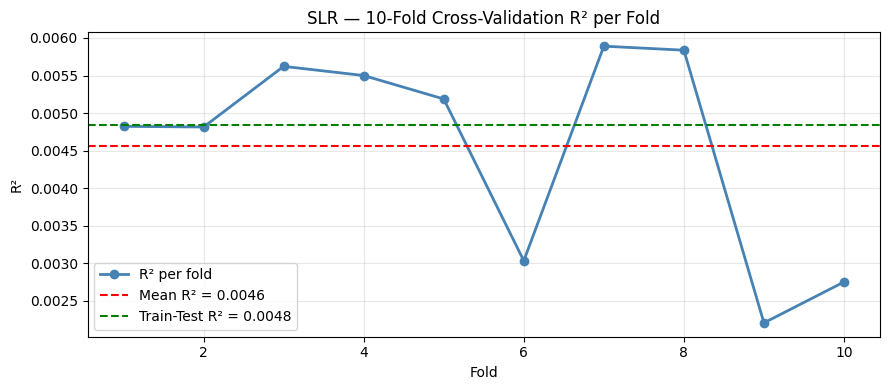

In [21]:
# ── Plot: CV fold scores ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, 11), slr_cv_r2, marker='o', color='steelblue',
        linewidth=2, label='R² per fold')
ax.axhline(slr_cv_r2.mean(), color='red', linestyle='--',
           linewidth=1.5, label=f'Mean R² = {slr_cv_r2.mean():.4f}')
ax.axhline(slr_r2, color='green', linestyle='--',
           linewidth=1.5, label=f'Train-Test R² = {slr_r2:.4f}')
ax.set_xlabel('Fold')
ax.set_ylabel('R²')
ax.set_title('SLR — 10-Fold Cross-Validation R² per Fold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretation of Results**

The 10-fold cross-validation confirms that the weak R² observed in the
train-test split is not a fluke — it is consistent across all 10 folds,
with a small standard deviation indicating stable (though low) performance.
This is itself a meaningful finding: elevation is a consistently poor predictor
of route distance regardless of which subset of data the model trains on.

### 3.1.2 Cross-Validation — Multiple Linear Regression

Apply the same 10-fold cross-validation procedure to the Multiple
Linear Regression model, which uses src_elevation, dst_elevation, lat_diff,
and lon_diff to predict distance_km. The purpose here is to verify that the
strong R² achieved in the train-test split (0.8468) holds consistently across
different data subsets and is not inflated by a favorable split.

In [22]:
# ── Data ───────────────────────────────────────────────────────────────────
mlr_features = ['src_elevation', 'dst_elevation', 'lat_diff', 'lon_diff']
mlr_cv_data  = master_df[mlr_features + ['distance_km']].dropna()
X_mlr_cv     = mlr_cv_data[mlr_features].values
y_mlr_cv     = mlr_cv_data['distance_km'].values

# ── 10-Fold Cross Validation ───────────────────────────────────────────────
mlr_cv_r2  = cross_val_score(LinearRegression(), X_mlr_cv, y_mlr_cv,
                              cv=kf, scoring='r2')
mlr_cv_mse = cross_val_score(LinearRegression(), X_mlr_cv, y_mlr_cv,
                              cv=kf, scoring='neg_mean_squared_error')
mlr_cv_mae = cross_val_score(LinearRegression(), X_mlr_cv, y_mlr_cv,
                              cv=kf, scoring='neg_mean_absolute_error')

print('MLR — 10-Fold Cross Validation Results')
print(f'  R²   mean: {mlr_cv_r2.mean():.4f}  std: {mlr_cv_r2.std():.4f}')
print(f'  MSE  mean: {(-mlr_cv_mse).mean():,.2f}  std: {(-mlr_cv_mse).std():,.2f}')
print(f'  RMSE mean: {np.sqrt(-mlr_cv_mse).mean():,.2f}  std: {np.sqrt(-mlr_cv_mse).std():,.2f}')
print(f'  MAE  mean: {(-mlr_cv_mae).mean():,.2f}  std: {(-mlr_cv_mae).std():,.2f}')

print('\nMLR — Comparison: Train-Test Split vs Cross-Validation')
print(f'  Train-Test R²  : {mlr_r2:.4f}')
print(f'  Cross-Val R²   : {mlr_cv_r2.mean():.4f}  (std: {mlr_cv_r2.std():.4f})')
print(f'  Train-Test RMSE: {mlr_rmse:,.2f}')
print(f'  Cross-Val RMSE : {np.sqrt(-mlr_cv_mse).mean():,.2f}')

MLR — 10-Fold Cross Validation Results
  R²   mean: 0.8445  std: 0.0148
  MSE  mean: 636,565.76  std: 53,680.02
  RMSE mean: 797.14  std: 33.76
  MAE  mean: 349.83  std: 5.66

MLR — Comparison: Train-Test Split vs Cross-Validation
  Train-Test R²  : 0.8468
  Cross-Val R²   : 0.8445  (std: 0.0148)
  Train-Test RMSE: 781.54
  Cross-Val RMSE : 797.14


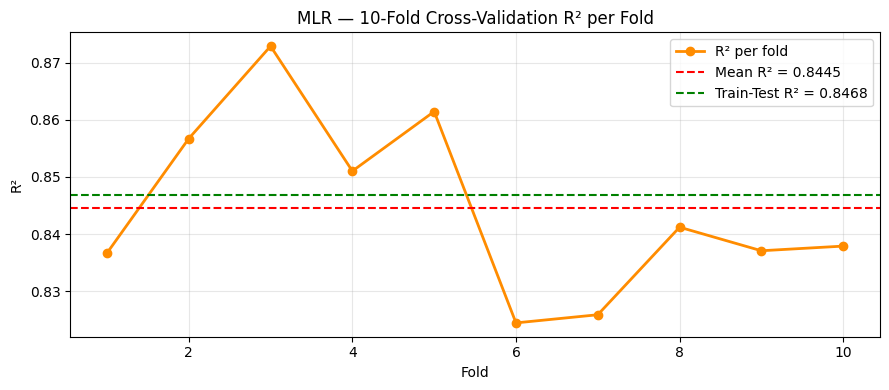

In [23]:
# ── Plot: CV fold scores ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, 11), mlr_cv_r2, marker='o', color='darkorange',
        linewidth=2, label='R² per fold')
ax.axhline(mlr_cv_r2.mean(), color='red', linestyle='--',
           linewidth=1.5, label=f'Mean R² = {mlr_cv_r2.mean():.4f}')
ax.axhline(mlr_r2, color='green', linestyle='--',
           linewidth=1.5, label=f'Train-Test R² = {mlr_r2:.4f}')
ax.set_xlabel('Fold')
ax.set_ylabel('R²')
ax.set_title('MLR — 10-Fold Cross-Validation R² per Fold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretation of Results**

The MLR cross-validation results show a consistently high R² (0.8445) across all 10 folds with a small standard deviation, confirming that the model generalizes well and is not overfitting to the training data. The cross-validation mean R² is close to the train-test split R² (0.8468), which validates that the 80/20 split used in the regression section was representative of the full dataset. Comparing with the SLR
cross-validation results, the improvement remains substantial and consistent,
confirming that the geographic supporting features genuinely contribute to
predicting route distance.

### 3.1.3 Cross-Validation — Logistic Regression

10-fold cross-validation is applied to the Logistic Regression
model, which classifies routes as international or domestic using src_elevation, dst_elevation, and distance_km. Logistic regression is evaluated using accuracy and log loss.

In [24]:
# ── Data ───────────────────────────────────────────────────────────────────
log_features = ['src_elevation', 'dst_elevation', 'distance_km']
log_cv_data  = master_df[log_features + ['is_international']].dropna()
X_log_cv     = log_cv_data[log_features].values
y_log_cv     = log_cv_data['is_international'].values

# Scale first — fit scaler on full data for CV
scaler_cv      = StandardScaler()
X_log_cv_sc    = scaler_cv.fit_transform(X_log_cv)

# ── 10-Fold Cross Validation ───────────────────────────────────────────────
log_cv_acc  = cross_val_score(LogisticRegression(max_iter=1000, random_state=42),
                               X_log_cv_sc, y_log_cv, cv=kf, scoring='accuracy')
log_cv_ll   = cross_val_score(LogisticRegression(max_iter=1000, random_state=42),
                               X_log_cv_sc, y_log_cv, cv=kf, scoring='neg_log_loss')

print('Logistic — 10-Fold Cross Validation Results')
print(f'  Accuracy  mean: {log_cv_acc.mean():.4f}  std: {log_cv_acc.std():.4f}')
print(f'  Log Loss  mean: {(-log_cv_ll).mean():.4f}  std: {(-log_cv_ll).std():.4f}')

log_abs_loss = 1 - np.mean(y_log_pred == y_log_test)
print('\nLogistic — Comparison: Train-Test Split vs Cross-Validation')
print(f'  Train-Test Accuracy  : {1 - log_abs_loss:.4f}')
print(f'  Cross-Val Accuracy   : {log_cv_acc.mean():.4f}  (std: {log_cv_acc.std():.4f})')

Logistic — 10-Fold Cross Validation Results
  Accuracy  mean: 0.7234  std: 0.0037
  Log Loss  mean: 0.5490  std: 0.0040

Logistic — Comparison: Train-Test Split vs Cross-Validation
  Train-Test Accuracy  : 0.7239
  Cross-Val Accuracy   : 0.7234  (std: 0.0037)


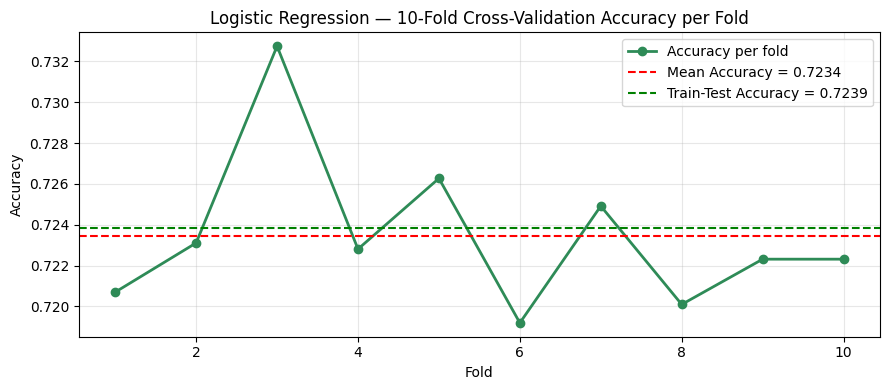

In [25]:
# ── Plot: CV fold scores ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, 11), log_cv_acc, marker='o', color='seagreen',
        linewidth=2, label='Accuracy per fold')
ax.axhline(log_cv_acc.mean(), color='red', linestyle='--',
           linewidth=1.5, label=f'Mean Accuracy = {log_cv_acc.mean():.4f}')
ax.axhline(1 - log_abs_loss, color='green', linestyle='--',
           linewidth=1.5, label=f'Train-Test Accuracy = {1-log_abs_loss:.4f}')
ax.set_xlabel('Fold')
ax.set_ylabel('Accuracy')
ax.set_title('Logistic Regression — 10-Fold Cross-Validation Accuracy per Fold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretation of Results**

The cross-validation accuracy across 10 folds (0.7234) is close to the train-test split accuracy (0.7239) with small standard deviation, confirming the logistic model is stable and not sensitive to which specific data subset it trains on. The model intentionally uses only elevation and distance as predictors, keeping the focus on infrastructure-related features. The result confirms that elevation carries a meaningful but limited signal for distinguishing domestic from international routes — high-elevation airports lean slightly toward domestic service, but route type is ultimately determined by a broader set of factors beyond what elevation alone can capture.

## 3.2 Bootstrap Method

The bootstrap method is applied to the MLR model, which was selected as the best-performing model based on its cross-validation R². Bootstrap resampling draws 1000 random samples with replacement from the full dataset — meaning the same row can appear multiple times in a single sample. The mean and standard deviation of this distribution are reported, along with a 95% confidence interval, to quantify how stable and reliable the model's error estimate is.

In [26]:
# ── Bootstrap on MLR ───────────────────────────────────────────────────────
mlr_boot_data = master_df[mlr_features + ['distance_km']].dropna()
X_boot        = mlr_boot_data[mlr_features].values
y_boot        = mlr_boot_data['distance_km'].values

n_iterations  = 1000
boot_rmse     = []

for i in range(n_iterations):
    # Resample with replacement
    X_bs, y_bs = resample(X_boot, y_boot, random_state=i)

    # Train on bootstrap sample, test on out-of-bag (original data)
    model_bs   = LinearRegression()
    model_bs.fit(X_bs, y_bs)
    y_bs_pred  = model_bs.predict(X_boot)
    rmse_bs    = np.sqrt(mean_squared_error(y_boot, y_bs_pred))
    boot_rmse.append(rmse_bs)

boot_rmse = np.array(boot_rmse)

print('Bootstrap Results — Multiple Linear Regression (1000 iterations)')
print(f'  RMSE Mean : {boot_rmse.mean():,.2f}')
print(f'  RMSE Std  : {boot_rmse.std():,.2f}')
print(f'  RMSE 95% CI: [{np.percentile(boot_rmse, 2.5):,.2f}, '
      f'{np.percentile(boot_rmse, 97.5):,.2f}]')

Bootstrap Results — Multiple Linear Regression (1000 iterations)
  RMSE Mean : 797.69
  RMSE Std  : 0.42
  RMSE 95% CI: [797.35, 798.87]


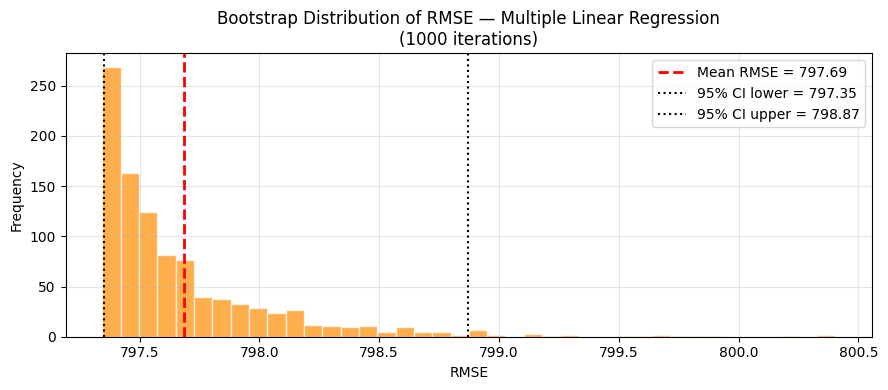

In [27]:
# ── Plot: Bootstrap RMSE distribution ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(boot_rmse, bins=40, color='darkorange', alpha=0.7, edgecolor='white')
ax.axvline(boot_rmse.mean(), color='red', linestyle='--',
           linewidth=2, label=f'Mean RMSE = {boot_rmse.mean():,.2f}')
ax.axvline(np.percentile(boot_rmse, 2.5), color='black', linestyle=':',
           linewidth=1.5, label=f'95% CI lower = {np.percentile(boot_rmse, 2.5):,.2f}')
ax.axvline(np.percentile(boot_rmse, 97.5), color='black', linestyle=':',
           linewidth=1.5, label=f'95% CI upper = {np.percentile(boot_rmse, 97.5):,.2f}')
ax.set_xlabel('RMSE')
ax.set_ylabel('Frequency')
ax.set_title('Bootstrap Distribution of RMSE — Multiple Linear Regression\n(1000 iterations)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretation of Results**

The bootstrap analysis over 1000 iterations produces a Mean RMSE of 797.69 km
with a very small standard deviation of 0.42 km. This indicates that the MLR
model's error estimate is highly stable — across 1000 different random resamples of the dataset, the model's prediction error barely fluctuates.

The 95% confidence interval [797.35, 798.87] is extremely narrow, spanning
only about 1.5 km. This means we can be 95% confident that the true prediction
error of the model falls within this tight range. The histogram visualizes this stability — the distribution is right-skewed with the vast
majority of RMSE values concentrated near the mean of 797.69, while only a
small number of resamples produced slightly higher errors

Overall, the bootstrap results strongly validate the reliability of the MLR
model.

## 3.3 Model Comparison — Adjusted R² and One-Standard-Error

Compare the SLR and MLR models using two methods.
- Adjusted R² is used to account for the difference in the number of features between the two models — since adjusted R² penalizes unnecessary complexity.
- One-standard-error rule is applied to the cross-validation RMSE
results to determine whether the added complexity of MLR is genuinely justified, or whether SLR performs within an acceptable margin of the best model. Logistic regression is excluded from this comparison as it solves a different task (classification).

1-SE threshold Explanation: The threshold is calculated as the best model's mean RMSE plus one standard error. It acts as a boundary — if a simpler model's RMSE falls within this boundary, its performance is considered close enough to the best model that the added complexity is not worth it. If it falls outside, the more complex model is the clear winner.

In [28]:
# ── Adjusted R² ────────────────────────────────────────────────────────────
def adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

n_slr = len(y_slr_test)
n_mlr = len(y_mlr_test)

adj_r2_slr = adjusted_r2(slr_r2, n_slr, 1)   # 1 feature
adj_r2_mlr = adjusted_r2(mlr_r2, n_mlr, 4)   # 4 features

print('Adjusted R² Comparison')
print(f'  SLR — R²: {slr_r2:.4f}  Adjusted R²: {adj_r2_slr:.4f}  (1 feature)')
print(f'  MLR — R²: {mlr_r2:.4f}  Adjusted R²: {adj_r2_mlr:.4f}  (4 features)')

# ── One-Standard-Error Rule ─────────────────────────────────────────────────
slr_cv_rmse = np.sqrt(-slr_cv_mse)
mlr_cv_rmse = np.sqrt(-mlr_cv_mse)

slr_mean_rmse = slr_cv_rmse.mean()
slr_se_rmse   = slr_cv_rmse.std() / np.sqrt(10)
mlr_mean_rmse = mlr_cv_rmse.mean()
mlr_se_rmse   = mlr_cv_rmse.std() / np.sqrt(10)

print('\nOne-Standard-Error Rule (CV RMSE)')
print(f'  SLR — Mean RMSE: {slr_mean_rmse:,.2f}  SE: {slr_se_rmse:,.2f}'
      f'  Range: [{slr_mean_rmse - slr_se_rmse:,.2f}, {slr_mean_rmse + slr_se_rmse:,.2f}]')
print(f'  MLR — Mean RMSE: {mlr_mean_rmse:,.2f}  SE: {mlr_se_rmse:,.2f}'
      f'  Range: [{mlr_mean_rmse - mlr_se_rmse:,.2f}, {mlr_mean_rmse + mlr_se_rmse:,.2f}]')

best_rmse     = min(slr_mean_rmse, mlr_mean_rmse)
threshold     = best_rmse + slr_se_rmse  # 1-SE threshold from best model
print(f'\n  Best RMSE     : {best_rmse:,.2f}')
print(f'  1-SE Threshold: {threshold:,.2f}')
print(f'  SLR within threshold? {"Yes" if slr_mean_rmse <= threshold else "No"}')
print(f'  MLR within threshold? {"Yes" if mlr_mean_rmse <= threshold else "No"}')

Adjusted R² Comparison
  SLR — R²: 0.0048  Adjusted R²: 0.0048  (1 feature)
  MLR — R²: 0.8468  Adjusted R²: 0.8468  (4 features)

One-Standard-Error Rule (CV RMSE)
  SLR — Mean RMSE: 2,020.46  SE: 12.82  Range: [2,007.64, 2,033.28]
  MLR — Mean RMSE: 797.14  SE: 10.68  Range: [786.46, 807.81]

  Best RMSE     : 797.14
  1-SE Threshold: 809.96
  SLR within threshold? No
  MLR within threshold? Yes


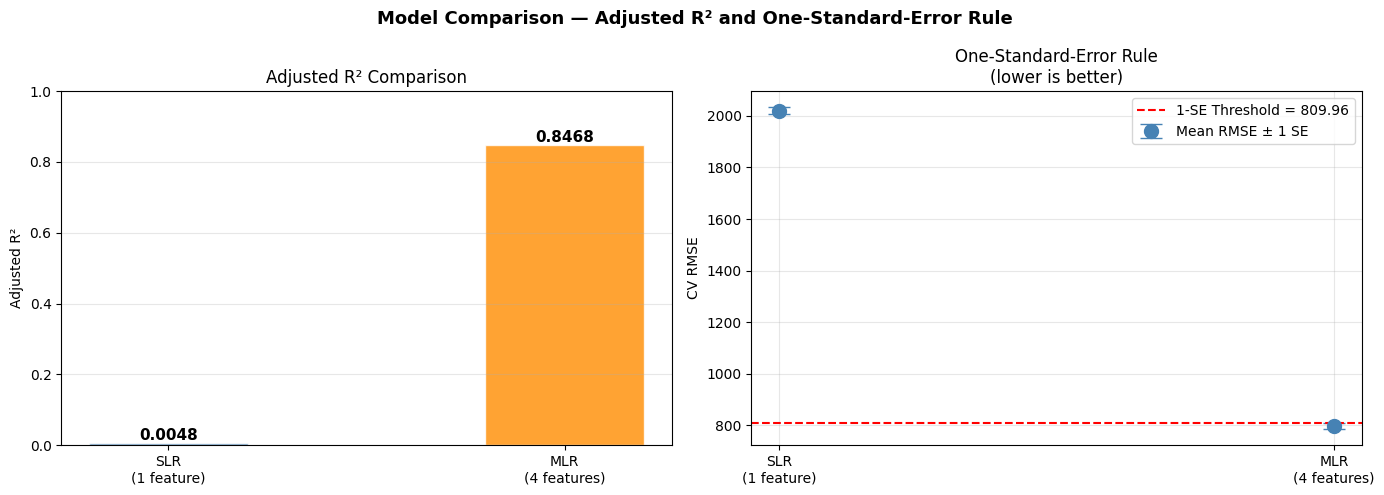

In [29]:
# ── Plot: Model Comparison ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Adjusted R² bar chart
ax1 = axes[0]
models    = ['SLR\n(1 feature)', 'MLR\n(4 features)']
adj_r2s   = [adj_r2_slr, adj_r2_mlr]
colors    = ['steelblue', 'darkorange']
bars      = ax1.bar(models, adj_r2s, color=colors, alpha=0.8, edgecolor='white', width=0.4)
for bar, val in zip(bars, adj_r2s):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')
ax1.set_ylabel('Adjusted R²')
ax1.set_title('Adjusted R² Comparison')
ax1.set_ylim(0, 1)
ax1.grid(axis='y', alpha=0.3)

# Right: One-standard-error plot
ax2 = axes[1]
means = [slr_mean_rmse, mlr_mean_rmse]
ses   = [slr_se_rmse,   mlr_se_rmse]
ax2.errorbar(models, means, yerr=ses, fmt='o', color='steelblue',
             markersize=10, capsize=8, linewidth=2, label='Mean RMSE ± 1 SE')
ax2.axhline(best_rmse + slr_se_rmse, color='red', linestyle='--',
            linewidth=1.5, label=f'1-SE Threshold = {best_rmse + slr_se_rmse:,.2f}')
ax2.set_ylabel('CV RMSE')
ax2.set_title('One-Standard-Error Rule\n(lower is better)')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('Model Comparison — Adjusted R² and One-Standard-Error Rule',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation of Results**

The adjusted R² comparison confirms that the improvement from SLR (0.0048)to MLR (0.8468) is genuine — the additional features (dst_elevation, lat_diff, lon_diff) contribute meaningful predictive power beyond what elevation alone provides, and the increase in adjusted R² is not simply a result of adding more variables. The one-standard-error rule further supports MLR as the preferred model — SLR's cross-validation RMSE does not fall within one standard error of MLR's best performance, meaning the
simpler model is not good enough and the added complexity of MLR is fully justified.

## 3.4 ROC Curve

The ROC curve evaluates the logistic regression model across all possible
classification thresholds, plotting the True Positive Rate against the
False Positive Rate. The Area Under the Curve (AUC) summarizes overall
model performance — a score of 1.0 represents a perfect classifier and
0.5 represents a random guess. This gives a more complete picture of
model quality than accuracy alone, since accuracy is only measured at
the default 0.5 threshold.

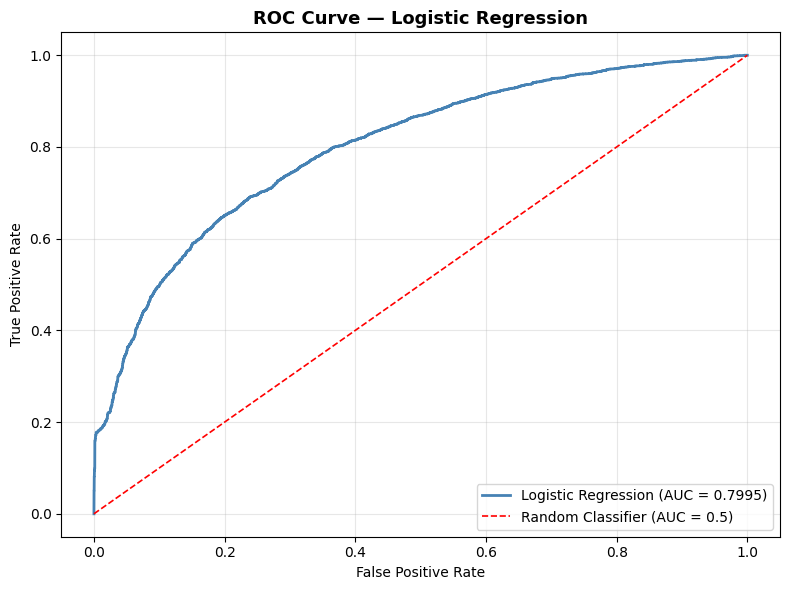

AUC Score: 0.7995


In [30]:
# ── ROC Curve for Logistic Regression ────────────────────────────────────
fpr, tpr, thresholds = roc_curve(y_log_test, y_log_pred_proba)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='steelblue', linewidth=2,
        label=f'Logistic Regression (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='red', linestyle='--',
        linewidth=1.2, label='Random Classifier (AUC = 0.5)')
ax.set_title('ROC Curve — Logistic Regression',
             fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'AUC Score: {roc_auc:.4f}')

**Interpretation of Results**

The ROC curve shows that the logistic regression model achieves an AUC
of 0.7995, meaning it correctly distinguishes between domestic and
international routes approximately 80% of the time across all possible
classification thresholds. This is notably higher than the 72% accuracy
reported at the default 0.5 threshold, suggesting that the model has
stronger discriminative ability than the accuracy score alone implies.

The curve rises steeply in the upper left before gradually flattening,
which indicates that the model captures a good portion of true
international routes while keeping false positives relatively low at
lower thresholds. The curve sits well above the red diagonal line which
represents a random classifier with an AUC of 0.5, confirming that the
model is learning meaningful patterns from elevation and distance features
rather than making random predictions. Overall, an AUC of 0.7995 is
considered a good result for a model using only three features without
any airline schedule or demand information.

## Conclusion

The cross-validation and bootstrap analysis confirmed and strengthened the
findings from the regression section. Running 10-fold cross-validation on all
three models showed that their performance metrics were stable and consistent
across folds, ruling out the possibility that the train-test split results were
a product of lucky data splitting. The weak R² of SLR held consistently across
all 10 folds, and so did the strong R² of MLR, which means both results
genuinely reflect the underlying relationships in the data rather than
overfitting or coincidence.

The bootstrap analysis on the MLR model produced a mean RMSE of 797.69 km
with a standard deviation of just 0.42 km across 1,000 iterations, which is
a strong indicator of model stability. The adjusted R² comparison and the
one-standard-error rule together confirmed that the additional features in
MLR contribute genuine predictive value rather than just complexity. Based on
all four evaluation methods, the Multiple Linear Regression is the strongest
and most reliable model in this project, and the evaluation section gave us
confidence that it generalizes well beyond the training data.

The ROC curve analysis further validated the logistic regression model,
achieving an AUC of 0.7995. This result confirms that the model's ability
to distinguish between domestic and international routes extends beyond
the 72% accuracy reported at the default threshold — the model maintains
strong discriminative performance across all possible classification
thresholds, reinforcing that elevation and distance carry genuine
predictive signal for route type classification.